In [ ]:
# p: Non Seasonal AR
# d: Non seasonal diff
# q: Non seasonal MA

#P: Seasonal AR
#D: Seasonal diff
#Q: Seasonal MA

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


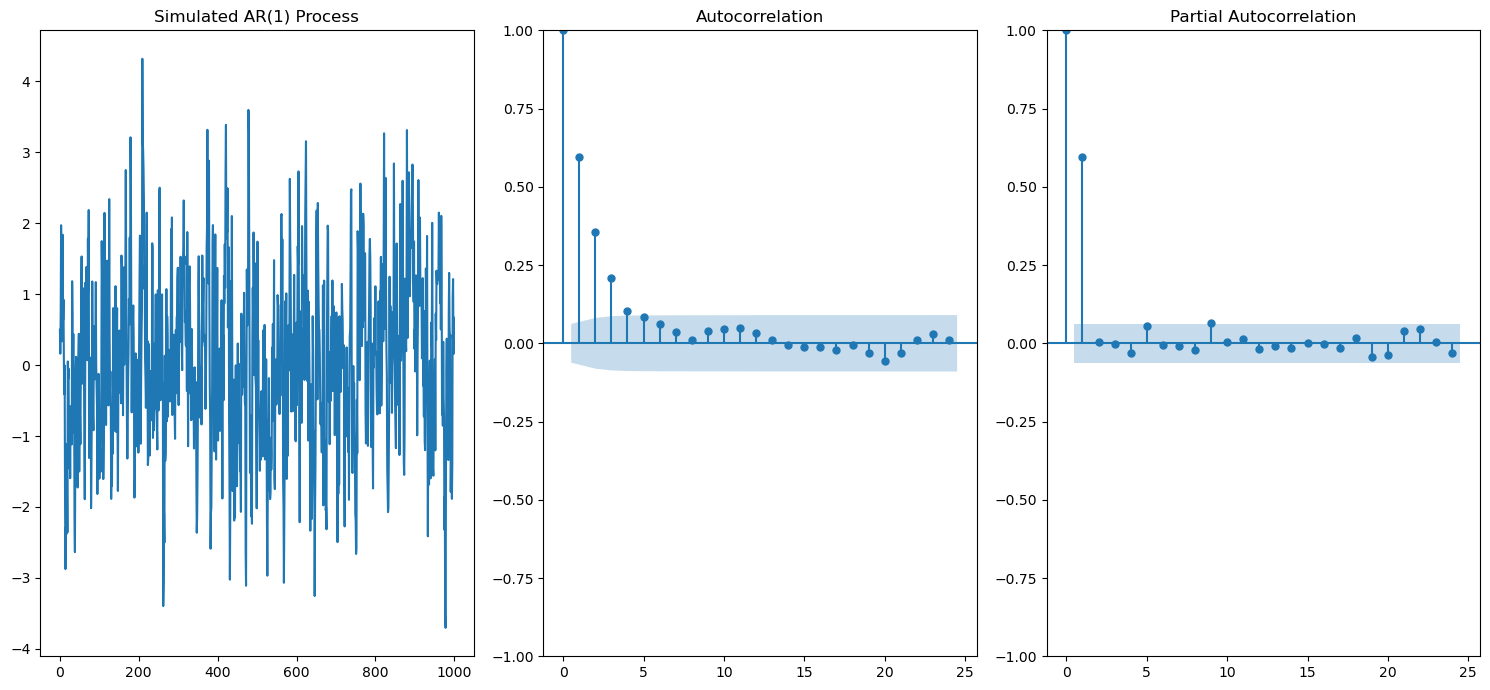

In [9]:
#2.1
# 1. Define parameters
phi_1 = 0.6
ar = np.array([1, -phi_1]) # AR polynomial: [1, -0.6]
ma = np.array([1])         # MA polynomial: [1]

# 2. Simulate the process (e.g., 300 observations)
np.random.seed(42) # For reproducibility
y = arma_generate_sample(ar, ma, nsample=1000)

# 3. Plotting (as requested in instructions)
fig, axes = plt.subplots(1, 3, figsize=(15,7))

# Time Series Plot
axes[0].plot(y)
axes[0].set_title("Simulated AR(1) Process")

# ACF Plot (up to lag 24 to see seasonal behavior)
plot_acf(y, lags=24, ax=axes[1])

# PACF Plot
plot_pacf(y, lags=24, ax=axes[2])

plt.tight_layout()
plt.show()

The AR(1) model can be described as $Y_t = 0.6Y_{t-1} + \epsilon_t$

The ACF shows geometric decay, starting at 0.6 for Lag 1. This indicates 60% autocorrelation between consecutive steps. The PACF also shows 0.6 at Lag 1 but cuts off at Lag 2. This is because the intermediate information at Lag 1 was removed, leaving only white noise.

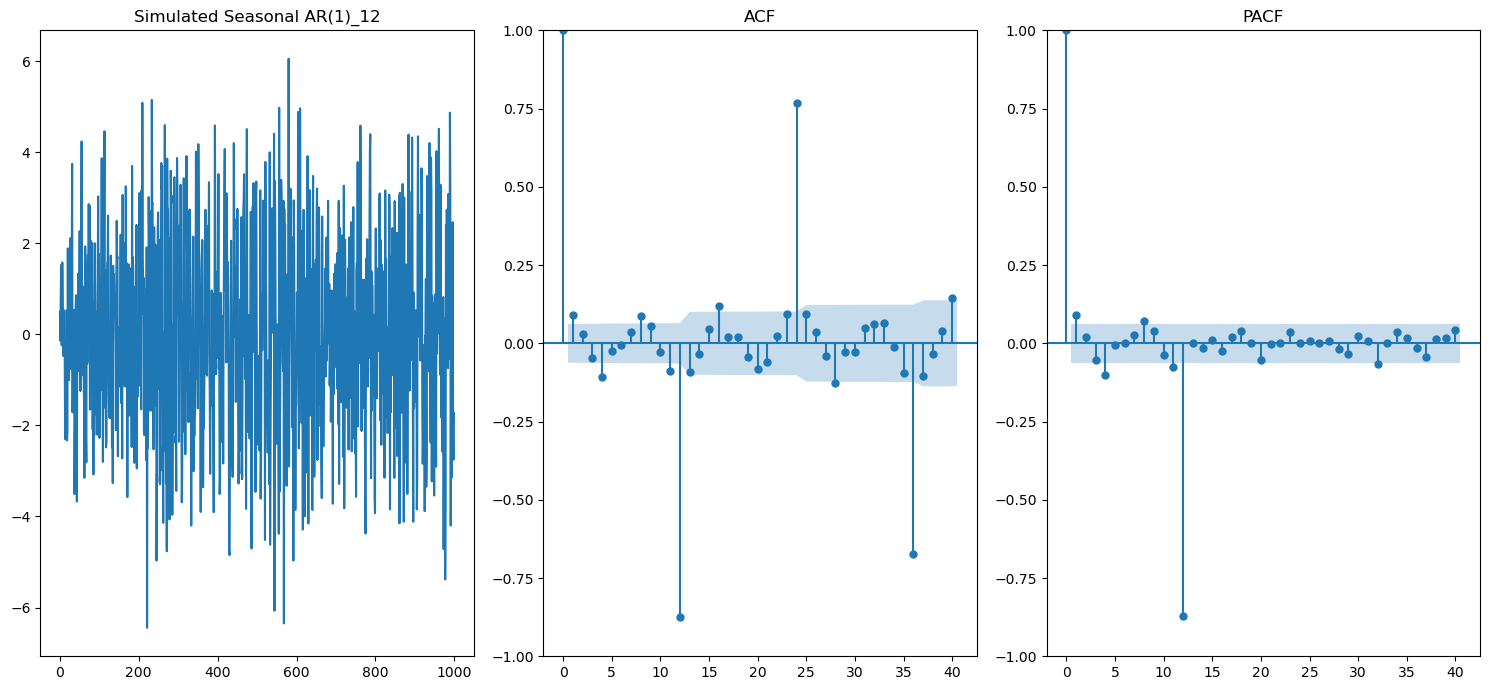

In [ ]:

# Model: (0,0,0) x (1,0,0)_12 with Phi_1 = -0.9
phi_1 = -0.9
# Create the AR polynomial: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -(-0.9)]
ar = np.zeros(13)
ar[0] = 1
ar[12] = -phi_1  # Sign is flipped for arma_generate_sample

ma = np.array([1])

# 2. Simulate
np.random.seed(42)
y = arma_generate_sample(ar, ma, nsample=1000)

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

axes[0].plot(y)
axes[0].set_title("Simulated Seasonal AR(1)_12")

# Look at 50 lags to see the seasonal spikes at 12, 24, 36, 48
plot_acf(y, lags=40, ax=axes[1], title="ACF")
plot_pacf(y, lags=40, ax=axes[2], title="PACF")

plt.tight_layout()
plt.show()

The AR(1) model here can be described as $Y_t = -0.9Y_{t-12} + \epsilon_t$

The AR(1) model is seasonal where the seasonal AR term is order 1. In the ACF plot, we see that there is oscillating autocorrelation at lag 12, lag 24 and lag 36. For the PACF model, also see negative correlation for lag 12 since phi_1 = -0.9. The other autocorrelations are in PACF are white noise.

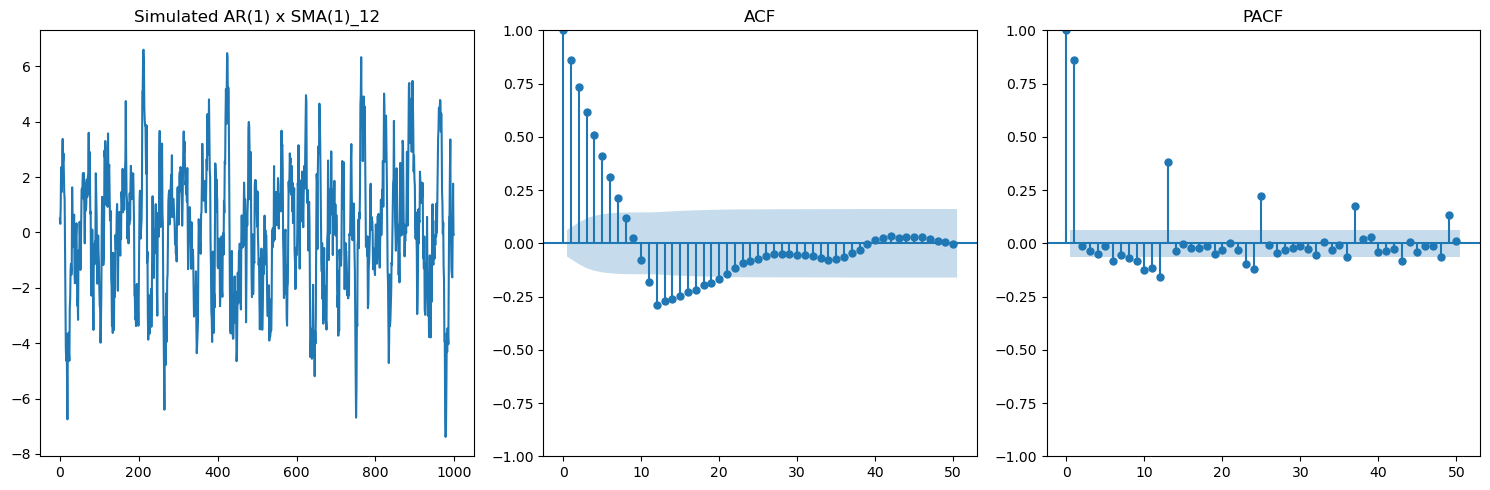

In [13]:

# Model: (1,0,0) x (0,0,1)_12 
# Parameters: phi_1 = 0.9, Theta_1 = -0.7
phi_1 = 0.9
Theta_1 = -0.7

# AR polynomial: (1 - 0.9B) -> [1, -0.9]
ar = np.array([1, -phi_1])
# MA polynomial: (1 - 0.7B^12) -> [1, 0, 0, ..., -0.7]
ma = np.zeros(13)
ma[0] = 1
ma[12] = Theta_1  # In statsmodels, MA signs usually match the operator form
# 2. Simulate
np.random.seed(42)
y = arma_generate_sample(ar, ma, nsample=1000)
# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(y)
axes[0].set_title("Simulated AR(1) x SMA(1)_12")

plot_acf(y, lags=50, ax=axes[1], title="ACF")
plot_pacf(y, lags=50, ax=axes[2], title="PACF")

plt.tight_layout()
plt.show()

The model can be described by the equation $Y_t = 0.9Y_{t-1} + \epsilon_t - 0.7\epsilon_{t-12}$.

This model is a multiplicative combination of a non-seasonal AR(1) and a seasonal MA(1) process. In the ACF plot, we see a slow exponential decay caused by the AR term ($0.9Y_{t-1}$). For the PACF, there is a significant positive correlation at lag 1, followed by a decaying seasonal pattern at lags 12, 24, and 36. The remaining lags fall within the bounds of white noise.

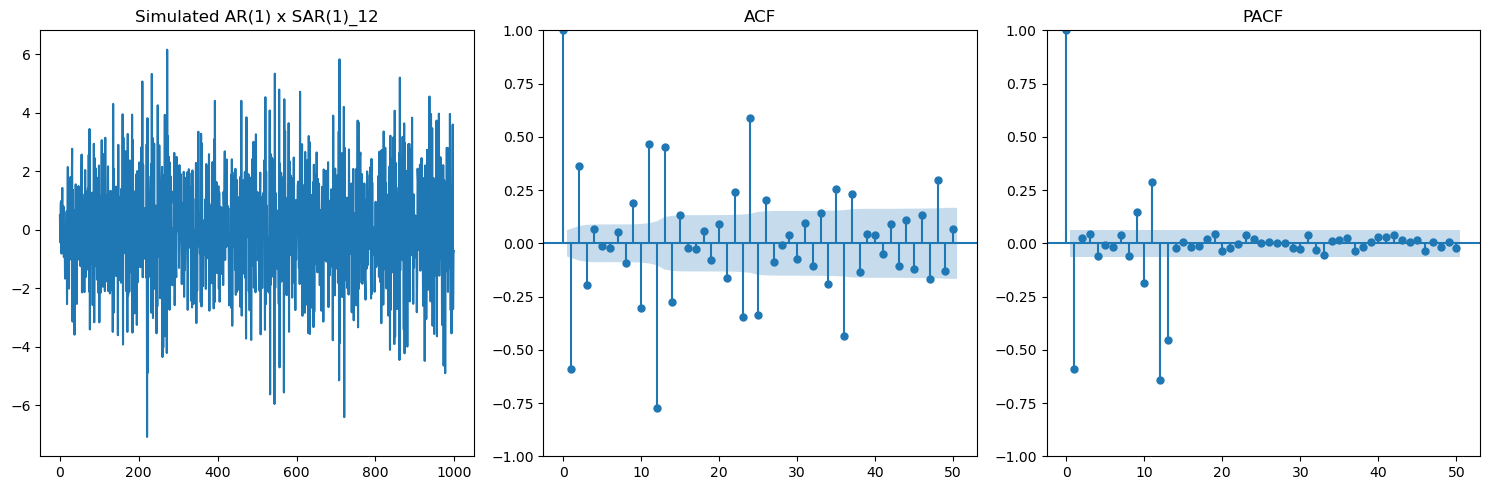

In [14]:
# Model 2.4: (1,0,0) x (1,0,0)_12
phi_1 = -0.6
Phi_1 = -0.8

# Expanded AR polynomial: [1, 0.6, 0, ..., 0.8, 0.48]
# Note: Signs in the 'ar' array match the operator form (1 + 0.6B + 0.8B^12 + 0.48B^13)
ar = np.zeros(14)
ar[0] = 1
ar[1] = -phi_1          # +0.6
ar[12] = -Phi_1         # +0.8
ar[13] = phi_1 * Phi_1  # +0.48

ma = np.array([1])

# Simulate
np.random.seed(42)
y24 = arma_generate_sample(ar, ma, nsample=1000)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(y24)
axes[0].set_title("Simulated AR(1) x SAR(1)_12")
plot_acf(y24, lags=50, ax=axes[1], title="ACF")
plot_pacf(y24, lags=50, ax=axes[2], title="PACF")
plt.tight_layout()
plt.show()


The model for 2.4 is described by the equation $Y_t = -0.6Y_{t-1} - 0.8Y_{t-12} - 0.48Y_{t-13} + \epsilon_t$.

This is a multiplicative seasonal AR model where both the non-seasonal and seasonal parts are order 1. In the ACF plot, we see an oscillating decay because both AR parameters are negative, causing the correlation to change signs at each lag. For the PACF, we see significant negative spikes at lag 1 and lag 12, followed by a smaller interaction spike at lag 13. The PACF then cuts off for the remaining lags, which is typical for a purely autoregressive process.